# Data Analysis Python Project- Costco Analysis

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Raw Data

In [2]:
# Warehouse dataset (json file)
df_wh = pd.read_json(r'/Users/aditisasankar/Downloads/costco_warehouses.json')

# Stock dataset (csv file)
df_stock = pd.read_csv(r'/Users/aditisasankar/Downloads/Costco_historical_data.csv')

# Fix timezone issue
df_stock['Date'] = pd.to_datetime(df_stock['Date'], utc=True)

In [3]:
df_stock.head()

,Date,Open,High,Low,Close,Volume,ticker,name
0,1986-07-09 04:00:00+00:00,7.140088,7.390617,7.056578,7.348862,1116800,COST,Costco Wholesale Corporation (COST) Historical...
1,1986-07-10 04:00:00+00:00,7.390619,7.432374,7.140089,7.307109,595600,COST,Costco Wholesale Corporation (COST) Historical...
2,1986-07-11 04:00:00+00:00,7.265354,7.307109,7.056579,7.056579,800400,COST,Costco Wholesale Corporation (COST) Historical...
3,1986-07-14 04:00:00+00:00,7.098335,7.098335,6.764296,6.847806,738000,COST,Costco Wholesale Corporation (COST) Historical...
4,1986-07-15 04:00:00+00:00,6.806050,6.806050,6.221481,6.639030,2059200,COST,Costco Wholesale Corporation (COST) Historical...


In [4]:
df_wh.head()

,stlocID,displayName,identifier,phone,fax,address1,city,state,country,zipCode,...,tireCenterHours,gasPrices,coreServices,specialtyDepartments,locationName,isShipToWarehouse,isWarehousePickup,enableShipToHome,isBusinessWarehouse,closeDate
0,1,1,1,(206) 622-3136,,4401 4TH AVE S,SEATTLE,WA,US,98134-2389,...,"[{'title': 'Mon-Fri.', 'code': 'open', 'time':...","{'warehouseid': '1', 'regular': '2.799', 'prem...","[{'name': 'Gas Station', 'localizedName': 'Gas...","[{'name': 'Auto Buying Program', 'localizedNam...",Seattle,True,True,False,False,NaN
1,2,2,2,(503) 252-2243,,4849 NE 138TH AVE,PORTLAND,OR,US,97230-3401,...,"[{'title': 'Mon-Fri.', 'code': 'open', 'time':...","{'warehouseid': '2', 'diesel': '2.899', 'regul...","[{'name': 'Gas Station', 'localizedName': 'Gas...","[{'name': 'ATM', 'localizedName': 'ATM', 'phon...",Portland,True,True,False,False,NaN
2,6,6,6,(206) 575-9191,,400 COSTCO DR STE 150,TUKWILA,WA,US,98188-4808,...,"[{'title': 'Mon-Fri.', 'code': 'open', 'time':...","{'warehouseid': '6', 'diesel': '2.959', 'regul...","[{'name': 'Gas Station', 'localizedName': 'Gas...","[{'name': 'Auto Buying Program', 'localizedNam...",Tukwila,True,True,False,False,NaN
3,8,8,8,(425) 827-1693,,8629 120TH AVE NE,KIRKLAND,WA,US,98033-5865,...,"[{'title': 'Mon-Fri.', 'code': 'open', 'time':...","{'warehouseid': '8', 'regular': '2.739', 'prem...","[{'name': 'Gas Station', 'localizedName': 'Gas...","[{'name': 'Auto Buying Program', 'localizedNam...",Kirkland,True,True,False,False,NaN
4,9,9,9,(503) 644-7615,,15901 SW JENKINS RD,ALOHA,OR,US,97006-5098,...,"[{'title': 'Mon-Fri.', 'code': 'open', 'time':...","{'warehouseid': '9', 'regular': '2.759', 'prem...","[{'name': 'Gas Station', 'localizedName': 'Gas...","[{'name': 'Auto Buying Program', 'localizedNam...",Aloha,True,True,False,False,NaN


# Data types with info

In [5]:
df_stock.info()

<class 'pandas.DataFrame'>
RangeIndex: 9948 entries, 0 to 9947
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   Date    9948 non-null   datetime64[us, UTC]
 1   Open    9948 non-null   float64            
 2   High    9948 non-null   float64            
 3   Low     9948 non-null   float64            
 4   Close   9948 non-null   float64            
 5   Volume  9948 non-null   int64              
 6   ticker  9948 non-null   str                
 7   name    9948 non-null   str                
dtypes: datetime64[us, UTC](1), float64(4), int64(1), str(2)
memory usage: 621.9 KB


In [6]:
df_wh.info()

<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 41 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   stlocID                   782 non-null    int64  
 1   displayName               782 non-null    int64  
 2   identifier                782 non-null    int64  
 3   phone                     782 non-null    str    
 4   fax                       782 non-null    str    
 5   address1                  782 non-null    str    
 6   city                      782 non-null    str    
 7   state                     782 non-null    str    
 8   country                   782 non-null    str    
 9   zipCode                   782 non-null    str    
 10  manager                   782 non-null    str    
 11  openDate                  782 non-null    str    
 12  tiresDepartmentPhone      782 non-null    str    
 13  distance                  782 non-null    float64
 14  latitude             

# Size Of Data

In [7]:
print("Size of Data:" ,df_wh.shape)

Size of Data: (782, 41)


In [8]:
print("Size of Data:" ,df_stock.shape)

Size of Data: (9948, 8)


# Field Information

In [9]:
df_wh.columns

Index(['stlocID', 'displayName', 'identifier', 'phone', 'fax', 'address1',
       'city', 'state', 'country', 'zipCode', 'manager', 'openDate',
       'tiresDepartmentPhone', 'distance', 'latitude', 'longitude',
       'parentGeoNodeID', 'active', 'languageID', 'hasGasDepartment',
       'hasTiresDepartment', 'hasFoodDepartment', 'hasHearingDepartment',
       'hasPharmacyDepartment', 'hasOpticalDepartment',
       'hasBusinessDepartment', 'hasPhotoCenterDepartment', 'warehouseHours',
       'pharmacyHours', 'upcomingHolidays', 'gasStationHours',
       'tireCenterHours', 'gasPrices', 'coreServices', 'specialtyDepartments',
       'locationName', 'isShipToWarehouse', 'isWarehousePickup',
       'enableShipToHome', 'isBusinessWarehouse', 'closeDate'],
      dtype='str')

In [10]:
df_stock.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'ticker', 'name'], dtype='str')

# Data types

In [11]:
df_wh.dtypes

stlocID                       int64
displayName                   int64
identifier                    int64
phone                           str
fax                             str
address1                        str
city                            str
state                           str
country                         str
zipCode                         str
manager                         str
openDate                        str
tiresDepartmentPhone            str
distance                    float64
latitude                    float64
longitude                   float64
parentGeoNodeID               int64
active                        int64
languageID                    int64
hasGasDepartment               bool
hasTiresDepartment             bool
hasFoodDepartment              bool
hasHearingDepartment           bool
hasPharmacyDepartment          bool
hasOpticalDepartment           bool
hasBusinessDepartment          bool
hasPhotoCenterDepartment       bool
warehouseHours              

In [12]:
df_stock.dtypes

Date      datetime64[us, UTC]
Open                  float64
High                  float64
Low                   float64
Close                 float64
Volume                  int64
ticker                    str
name                      str
dtype: object

# Create Warehouse Summary Dataset

In [13]:
warehouse_summary = df_wh.groupby("country").size().reset_index(name="warehouse_count")

warehouse_summary.head()

,country,warehouse_count
0,AU,12
1,CA,99
2,CH,1
3,ES,2
4,FR,1


In [14]:
stock_summary = df_stock.groupby("Date").agg(
    avg_close_price=("Close", "mean"),
    total_volume=("Volume", "sum"),
    max_price=("High", "max"),
    min_price=("Low", "min")
).reset_index()

stock_summary.head()

,Date,avg_close_price,total_volume,max_price,min_price
0,1986-07-09 04:00:00+00:00,7.348862,1116800,7.390617,7.056578
1,1986-07-10 04:00:00+00:00,7.307109,595600,7.432374,7.140089
2,1986-07-11 04:00:00+00:00,7.056579,800400,7.307109,7.056579
3,1986-07-14 04:00:00+00:00,6.847806,738000,7.098335,6.764296
4,1986-07-15 04:00:00+00:00,6.639030,2059200,6.806050,6.221481


# Create stock yearly summary

In [15]:
df_stock['year'] = df_stock['Date'].dt.year

stock_summary = df_stock.groupby("year").agg(
    avg_close_price=('Close','mean'),
    total_volume=('Volume','sum')
).reset_index()

stock_summary.head()

,year,avg_close_price,total_volume
0,1986,5.947019,98634400
1,1987,6.921331,221716400
2,1988,6.274624,176827200
3,1989,7.001653,289562000
4,1990,6.155466,326288000


# Create one combined dataset

In [16]:
total_warehouses = len(df_wh)

stock_summary['total_warehouses'] = total_warehouses

final_dataset = stock_summary
final_dataset.head()

,year,avg_close_price,total_volume,total_warehouses
0,1986,5.947019,98634400,782
1,1987,6.921331,221716400,782
2,1988,6.274624,176827200,782
3,1989,7.001653,289562000,782
4,1990,6.155466,326288000,782


# Stock Price Trend

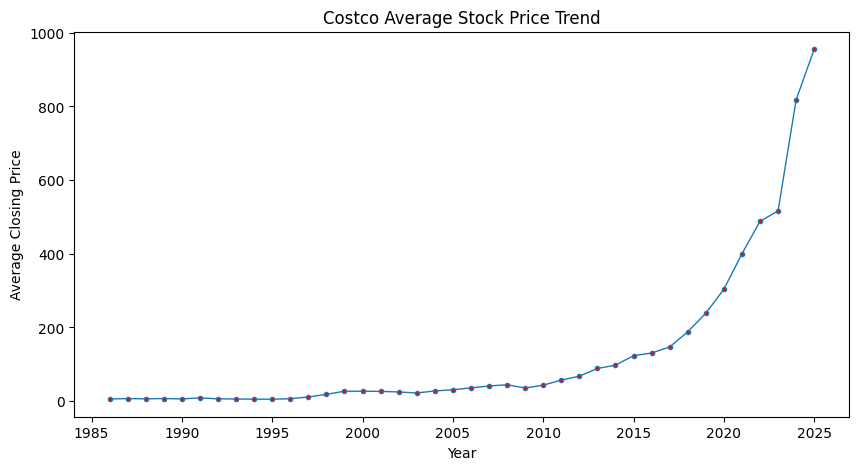

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(final_dataset['year'], final_dataset['avg_close_price'],marker='o',linestyle='-',markersize=3,markerfacecolor='red', linewidth=1 )
plt.title("Costco Average Stock Price Trend")
plt.xlabel("Year")
plt.ylabel("Average Closing Price")
plt.show()

Seprate Visulization

* Stock performance
* Warehouse distribution

# Trading Volume (Bar Chart)

Definition: Total number of Costco shares traded.

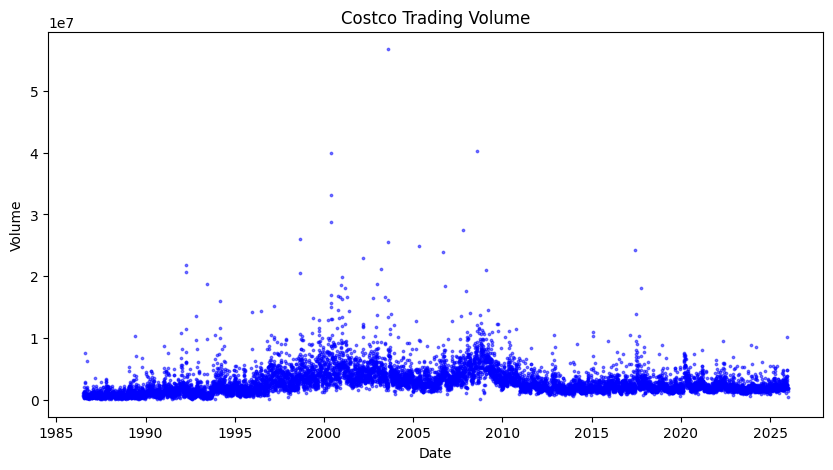

In [18]:
plt.figure(figsize=(10,5))
# Use plt.scatter instead of plt.plot
plt.scatter(df_stock['Date'], df_stock['Volume'], s=3, alpha=0.5, c='blue')

plt.title("Costco Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()


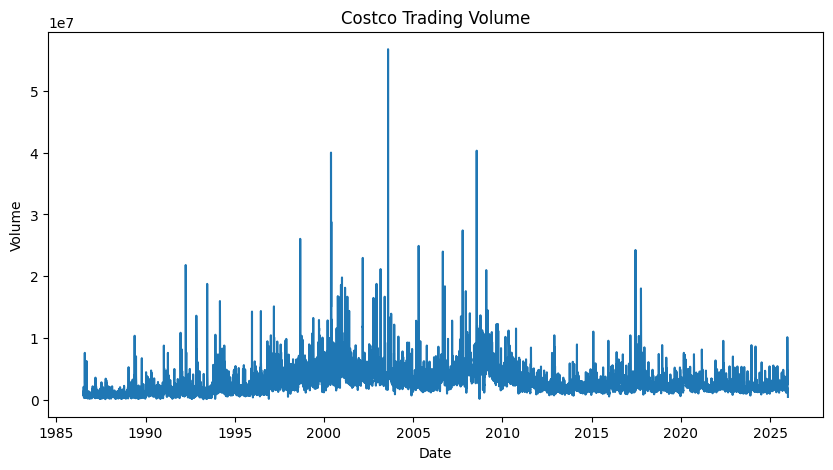

In [19]:
plt.figure(figsize=(10,5))
plt.plot(df_stock['Date'], df_stock['Volume'])
plt.title("Costco Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

# KPI: Warehouse Distribution

Definition: Number of warehouses per country.

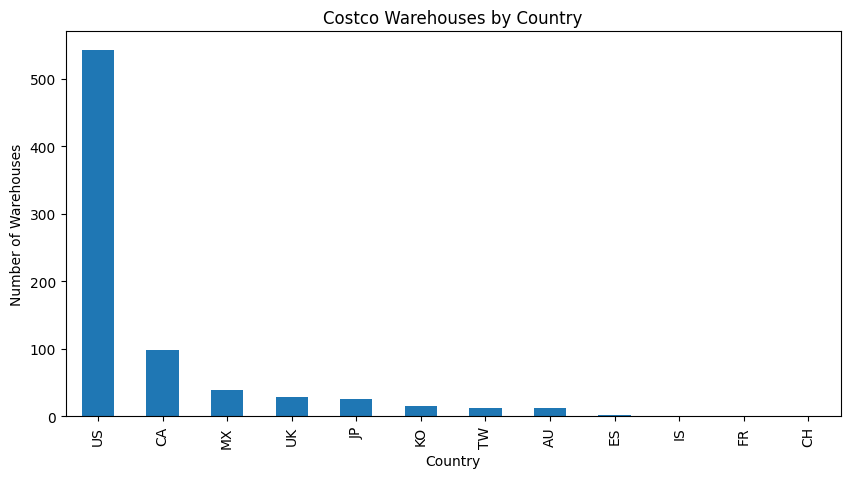

In [20]:
warehouse_country = df_wh['country'].value_counts()

warehouse_country.plot(kind='bar', figsize=(10,5))
plt.title("Costco Warehouses by Country")
plt.xlabel("Country")
plt.ylabel("Number of Warehouses")
plt.show()

# KPI: Global Store Locations

Definition: Geographic distribution of warehouses

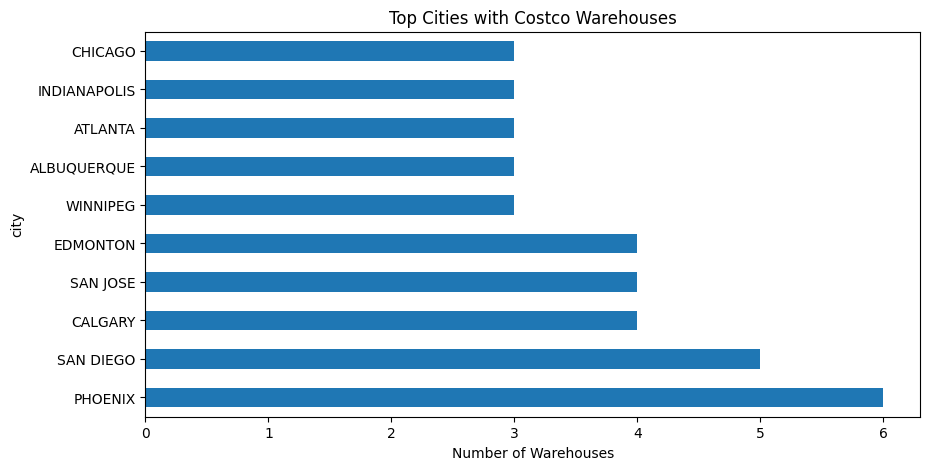

In [21]:
stores_by_city = df_wh['city'].value_counts().head(10)

stores_by_city.plot(kind='barh', figsize=(10,5))
plt.title("Top Cities with Costco Warehouses")
plt.xlabel("Number of Warehouses")
plt.show()

In [22]:
# Count warehouses per country
warehouse_country = df_wh.groupby("country").size().reset_index(name="Total_Warehouses")

warehouse_country.head()

,country,Total_Warehouses
0,AU,12
1,CA,99
2,CH,1
3,ES,2
4,FR,1


# Warehouse Distribution by Region

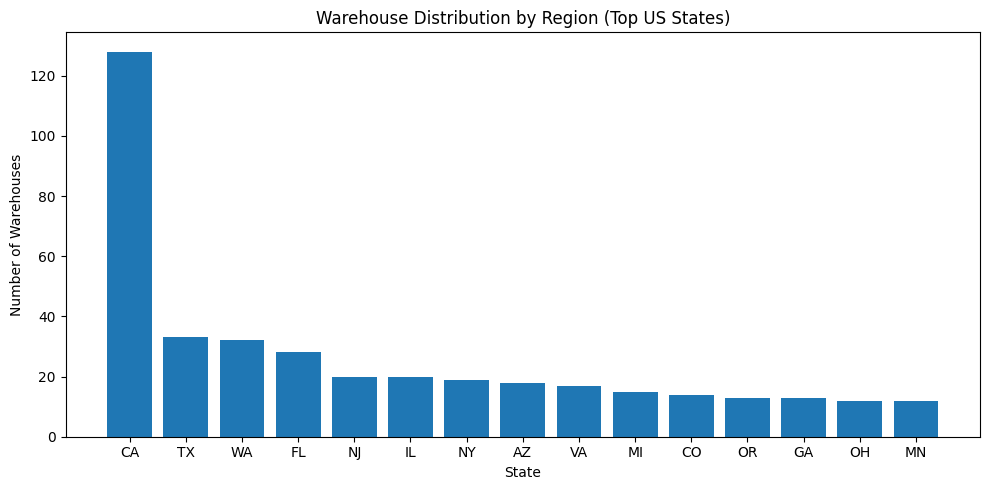

In [23]:
us_df = df_wh[df_wh["country"] == "US"]

region_counts = us_df["state"].value_counts().head(15)

plt.figure(figsize=(10,5))
plt.bar(region_counts.index, region_counts.values)
plt.title("Warehouse Distribution by Region (Top US States)")
plt.xlabel("State")
plt.ylabel("Number of Warehouses")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Warehouse Density

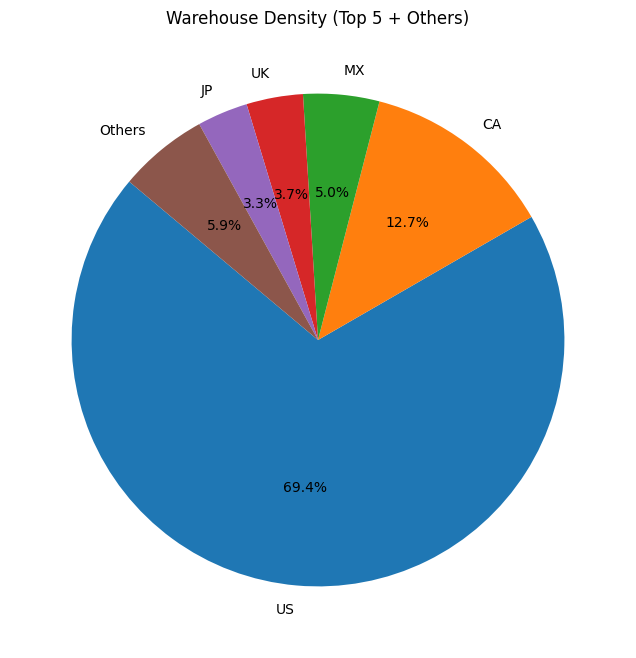

In [39]:
counts = df_wh["country"].value_counts()

top5 = counts.head(5)
others = counts[5:].sum()

final_data = top5.copy()
final_data["Others"] = others

plt.figure(figsize=(8,8))

plt.pie(
    final_data,
    labels=final_data.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Warehouse Density (Top 5 + Others)")
plt.show()